## This experiment is to investigate the effect of unbalanced dataset and how it affects overall accuracy and per-class-accuracy

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy

import numpy as np
import scipy.stats as stats

import polars as pl
import plotly.express as px
import plotly.io as pio

# show all columns without truncation
pl.Config.set_tbl_cols(-1)

polars.config.Config

In [24]:
# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

raw_data = pl.read_csv(url, separator=';',  infer_schema_length=10000)

raw_data.head()

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0.68,9.8,5
7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [25]:
# check the datatypes
raw_data.schema

Schema([('fixed acidity', Float64),
        ('volatile acidity', Float64),
        ('citric acid', Float64),
        ('residual sugar', Float64),
        ('chlorides', Float64),
        ('free sulfur dioxide', Float64),
        ('total sulfur dioxide', Float64),
        ('density', Float64),
        ('pH', Float64),
        ('sulphates', Float64),
        ('alcohol', Float64),
        ('quality', Int64)])

In [26]:
# find rows with atleast one missing NA
# which is none
raw_data.filter(pl.any_horizontal(pl.all().is_null()))

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64


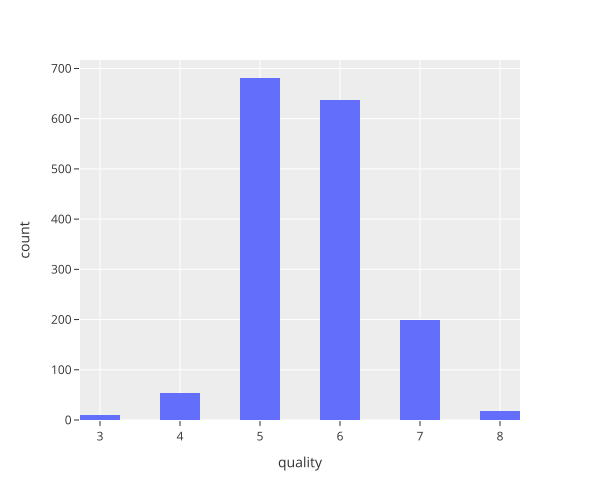

In [27]:
# inspect the distribution of the label
# we see that the label are normally distributed
# what we want to achieve in this experiment is feature engineer to have imbalanced data
fig = px.histogram(
    raw_data,
    x='quality',
    nbins=20
)

fig.update_layout(template='ggplot2', width=600)

fig.show(renderer='svg')

## Function to prep the dataset - data engineer the dataset and makes it imbalance

In [28]:
def createDataset(splitThreshold):
    # Engineer quality labels
    temp_data = (raw_data
        .with_columns(
            pl.when(pl.col('quality') > splitThreshold)
            .then(1)
            .otherwise(0)
            .alias('quality')
        )
    )

    # Extract features and labels as numpy arrays
    features = temp_data.select(pl.exclude('quality')).to_numpy().astype(np.float32)
    labels = temp_data.select(pl.col('quality')).to_numpy().squeeze().astype(np.int64)

    # Split before scaling to prevent data leakage
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42
    )

    # Fit scaler on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Create datasets and loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    batchsize = 8
    train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

    return train_loader, test_loader

In [29]:
# Test the dataset and examine class distribution
# Note: threshold=5 provides roughly balanced classes (unlike 4 or 6)
train_loader, test_loader = createDataset(5)

# Analyze class balance in training set
train_labels = train_loader.dataset.tensors[1]
low_quality_count = (train_labels == 0).sum().item()
high_quality_count = (train_labels == 1).sum().item()
total_samples = len(train_labels)

print(f"Training set distribution:")
print(f"  Low-rated wines:  {low_quality_count:4d} ({low_quality_count/total_samples:.1%})")
print(f"  High-rated wines: {high_quality_count:4d} ({high_quality_count/total_samples:.1%})")
print(f"  Total samples:    {total_samples:4d}")

Training set distribution:
  Low-rated wines:   603 (47.1%)
  High-rated wines:  676 (52.9%)
  Total samples:    1279


In [30]:
# unbalanced if 6
train_loader, test_loader = createDataset(6)

# Analyze class balance in training set
train_labels = train_loader.dataset.tensors[1]
low_quality_count = (train_labels == 0).sum().item()
high_quality_count = (train_labels == 1).sum().item()
total_samples = len(train_labels)

print(f"Training set distribution:")
print(f"  Low-rated wines:  {low_quality_count:4d} ({low_quality_count/total_samples:.1%})")
print(f"  High-rated wines: {high_quality_count:4d} ({high_quality_count/total_samples:.1%})")
print(f"  Total samples:    {total_samples:4d}")

Training set distribution:
  Low-rated wines:  1109 (86.7%)
  High-rated wines:  170 (13.3%)
  Total samples:    1279


## Define a model class and components for the experiment

In [31]:
# construct the class for the model
class ANNmodel(nn.Module):
    def __init__(self, nUnits, nLayers):
        super().__init__()

        # create a dictionary to store the layers
        self.layers = nn.ModuleDict()

        ### input layer
        self.layers['input'] = nn.Linear(11, nUnits)

        ### generate the hidden layers
        for i in range(nLayers):
            self.layers[f"hidden{i}"] = nn.Linear(nUnits, nUnits)

        ### output layer
        self.layers['output'] = nn.Linear(nUnits, 1)

    # forward pass
    def forward(self, x):
        x = F.relu(self.layers['input'](x))

        # hidden layers
        for i in range(len(self.layers) - 2):  # -2 for input and output layers
            x = F.relu(self.layers[f"hidden{i}"](x))

        # return output layer
        x = self.layers['output'](x)
        return x

In [32]:
# create model componenets
def createANNnet(train_loader, nUnits, nLayers, learningRate=0.01, epochStep=10, gamma=1/2):
    model = ANNmodel(nUnits, nLayers)
    lossfunc = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

    step_size = len(train_loader) * epochStep
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    return model, lossfunc, optimizer, scheduler

In [33]:
# function to train the model with early stopping
def trainModel(train_loader, test_loader, nUnits, nLayers, numepochs=500, toggleDynamic=False):
    # define an empty list
    training_progress = pl.DataFrame(
        schema=[
            ('iteration', pl.Int64),
            ('epoch', pl.Int64),
            ('train_loss', pl.Float64),
            ('train_acc', pl.Float64),
            ('test_loss', pl.Float64),
            ('test_acc', pl.Float64),
            ('learning_rate', pl.Float64)
        ]
    )
    iteration = 0

    # create the ann Model
    model, lossfunc, optimizer, scheduler = createANNnet(
        train_loader, nUnits, nLayers, learningRate=0.001, epochStep=10, gamma=1/2,
    )

    # get test data once
    X_testTL, y_testTL = next(iter(test_loader))

    # Early stopping parameters
    patience = 200
    best_loss = float('inf')
    no_improve_count = 0
    best_model = None

    # training loop
    for epoch in range(numepochs):
        model.train()

        epoch_train_loss = 0
        epoch_train_acc = 0
        num_batches = 0

        # iterate through the training batches
        for X_trainTL, y_trainTL in train_loader:
            yhat_train = model(X_trainTL)
            # Convert labels to float for BCEWithLogitsLoss
            y_trainTL_float = y_trainTL.float()
            train_loss = lossfunc(yhat_train.squeeze(), y_trainTL_float)

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            if toggleDynamic:
                scheduler.step()
                current_lrs = scheduler.get_last_lr()[0]
            else:
                current_lrs = optimizer.param_groups[0]['lr']

            # accuracy calculation for single output with sigmoid
            train_predictions = (torch.sigmoid(yhat_train) > 0.5).float().squeeze()
            train_matches = (train_predictions == y_trainTL_float).float()
            train_acc = 100 * torch.mean(train_matches)

            epoch_train_loss += train_loss.item()
            epoch_train_acc += train_acc.item()
            num_batches += 1

        # end of epoch: evaluate test Once
        model.eval()
        with torch.no_grad():
            yhat_test = model(X_testTL)
            y_testTL_float = y_testTL.float()
            test_loss = lossfunc(yhat_test.squeeze(), y_testTL_float)
            test_predictions = (torch.sigmoid(yhat_test) > 0.5).float().squeeze()
            test_matches = (test_predictions == y_testTL_float).float()
            test_acc = 100 * torch.mean(test_matches)

        # log single row per epoch
        new_row = pl.DataFrame([{
            'iteration': iteration,
            'epoch': epoch,
            'train_loss': epoch_train_loss / num_batches,
            'train_acc': epoch_train_acc / num_batches,
            'test_loss': test_loss.item(),
            'test_acc': test_acc.item(),
            'learning_rate': current_lrs
        }])

        training_progress = pl.concat([training_progress, new_row])
        iteration += 1

        # Early stopping check
        if test_loss < best_loss:
            best_loss = test_loss.item()
            no_improve_count = 0
            best_model = copy.deepcopy(model)
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"Early stopping at epoch {epoch+1} - No improvement for {patience} epochs")
                break

        if epoch % 10 == 0 or epoch == numepochs - 1:
            print(
                f"Epoch {epoch+1}/{numepochs} - "
                f"Training: Loss={epoch_train_loss / num_batches:.4f}, "
                f"Accuracy={epoch_train_acc / num_batches:.2f}% | "
                f"Testing: Loss={test_loss.item():.4f}, "
                f"Accuracy={test_acc.item():.2f}% | "
                f"Learning Rate: {current_lrs:.6f}"
            )

    # Fixed: Return both training progress and model
    return training_progress, best_model if best_model is not None else model

## Start the experiment loop

In [34]:
# define the model parameters
numlayers = 2
numunits = 32
qualityThresholds = [4,5,6]

In [35]:
# crate a loop for those model parameters and start the experiment
all_results = []

for thres in qualityThresholds:
    print(f"\n=== Training with quality threshold: {thres} ===")

    # create dataset with different iteration of quality threshold
    train_loader, test_loader = createDataset(thres)

    # Fixed: Unpack the tuple return
    training_progress, trained_model = trainModel(
        train_loader, test_loader,
        nUnits=numunits, nLayers=numlayers,
        numepochs=500, toggleDynamic=False
    )

    # create a column to annotate the number of unit and layers in each loop
    training_progress = (
        training_progress
        .with_columns(
            quality_threshold=pl.lit(thres)
        )
    )

    # append the returning dataframe to all_results
    all_results.append(training_progress)

combined_results = pl.concat(all_results)



=== Training with quality threshold: 4 ===
Epoch 1/500 - Training: Loss=0.3313, Accuracy=87.34% | Testing: Loss=0.1505, Accuracy=96.56% | Learning Rate: 0.001000
Epoch 11/500 - Training: Loss=0.1270, Accuracy=95.99% | Testing: Loss=0.1132, Accuracy=96.56% | Learning Rate: 0.001000
Epoch 21/500 - Training: Loss=0.1005, Accuracy=96.07% | Testing: Loss=0.1302, Accuracy=96.56% | Learning Rate: 0.001000
Epoch 31/500 - Training: Loss=0.0803, Accuracy=97.25% | Testing: Loss=0.1558, Accuracy=96.25% | Learning Rate: 0.001000
Epoch 41/500 - Training: Loss=0.0471, Accuracy=97.96% | Testing: Loss=0.2194, Accuracy=96.25% | Learning Rate: 0.001000
Epoch 51/500 - Training: Loss=0.0229, Accuracy=99.21% | Testing: Loss=0.2800, Accuracy=95.31% | Learning Rate: 0.001000
Epoch 61/500 - Training: Loss=0.0110, Accuracy=99.69% | Testing: Loss=0.4243, Accuracy=96.88% | Learning Rate: 0.001000
Epoch 71/500 - Training: Loss=0.0086, Accuracy=99.84% | Testing: Loss=0.4190, Accuracy=96.88% | Learning Rate: 0.0010

## Results: Overall accuracy of the model & caveat

In [36]:
grouped_data = (
    combined_results
    .group_by('quality_threshold','epoch')
    .agg(pl.selectors.numeric().mean().name.prefix('mean_'))
    .sort('quality_threshold', 'epoch', descending=[False, False])
)

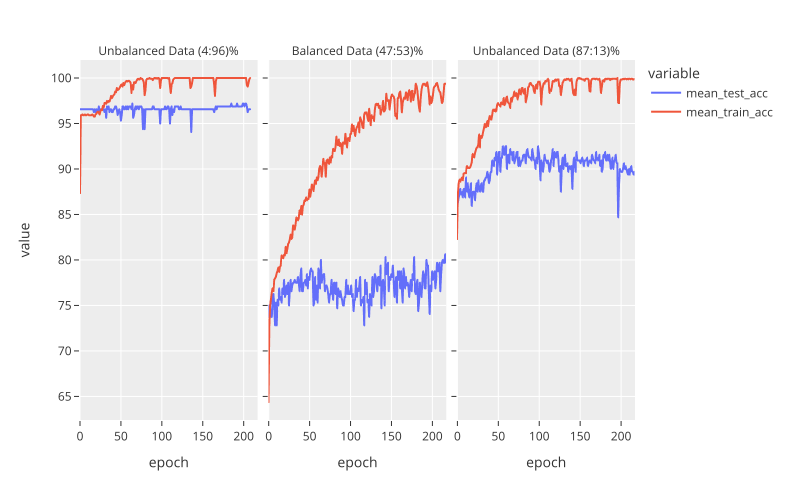

In [37]:
fig = px.line(
    grouped_data,
    x='epoch',
    y=['mean_test_acc', 'mean_train_acc'],
    facet_col='quality_threshold',
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# Custom subtitles for each facet
custom_titles = {
    '4': 'Unbalanced Data (4:96)%',
    '5': 'Balanced Data (47:53)%',
    '6': 'Unbalanced Data (87:13)%'
}

fig.for_each_annotation(
    lambda a: a.update(text=custom_titles.get(a.text.split("=")[-1], a.text))
)


fig.update_layout(template='ggplot2', width=800)
fig.show(renderer='svg')

Interpretation:

* Reminded a threshold of 5 is when the label data is relatively balanced not - treshold of 4 and 6 are inbalanced.
* Overall accuracy it appears the balanced dataset appears to be performing worse than imbalanced data - in fact the worst performing between the bunch
* however, the overall accuracy is not granular enough.
* it would be a better idea to check the classification accuracy per class ( also known as per-class recall or sensitivity) when dealing with unbalanced data.

The reason:


1) **the accuracy paradox**: overall accuracy can be highly misleading and a simple model can have high accuracy because it is predicting the majority class.
  * for instance, if 95% of the data is A class, and 5% is the B class - if the model only predicts for A class it will stil be 95% correct; and will be totally useless for the B class

2) **Bias towards Manjority Class:** deep learning models by default often learn to optimize for overall accuracy. With imbalanced data, this can lead them to prioritize correctly classifiying th majority class. This is something important for example, fraud detection, rare disease, diagnosis, anomaly detection.

3) **Understanding Skewed Predictions:** checking per class accuracy will immediately reveal if your model is disproportionately better at classifying certain classes than others.


Example:

Index:     0    1    2    3    4
y:         0    1    0    1    1
correct:   1.0  0.0  1.0  1.0  0.0

For low quality (y==0):
- Positions 0,2 have y==0
- correct[0]=1.0, correct[2]=1.0  
- Average = (1.0 + 1.0)/2 = 1.0 = 100%

For high quality (y==1):  
- Positions 1,3,4 have y==1
- correct[1]=0.0, correct[3]=1.0, correct[4]=0.0
- Average = (0.0 + 1.0 + 0.0)/3 = 0.33 = 33%

In [38]:
# with extra suggestions from Claude AI to implement the per-class-accuracy
all_results = []
all_training_progress = []

for thres in qualityThresholds:
    print(f"\n=== Training with threshold {thres} ===")

    # Create dataset and train model
    train_loader, test_loader = createDataset(thres)
    training_progress, trained_model = trainModel(
        train_loader, test_loader,
        nUnits=numunits, nLayers=numlayers,
        numepochs=500, toggleDynamic=False
    )

    # Add threshold info to training progress and store separately
    training_progress = training_progress.with_columns(quality_threshold=pl.lit(thres))
    all_training_progress.append(training_progress)

    # Compute per-class accuracy
    trained_model.eval() # get one batch of test data
    with torch.no_grad():
        '''correct = which predictions were right'''
        X, y = next(iter(test_loader))
        predictions = torch.sigmoid(trained_model(X)).squeeze() # get the probability score between 0 and 1
        binary_preds = (predictions > 0.5).float() # convert to binary prediction with 0.5 is the threshold
        correct = (binary_preds == y.float()).float() # calculate the correctness

        # Per-class accuracy
        '''
        correct[y == 0] = corectness ofr low quality samples
        correct[y == 1] = corectness ofr high quality samples
        torch.mean(correct[y==0]) calculates the fraction of correct predictions for this class
        '''
        low_acc = 100 * torch.mean(correct[y == 0]) if torch.sum(y == 0) > 0 else 0
        high_acc = 100 * torch.mean(correct[y == 1]) if torch.sum(y == 1) > 0 else 0
        overall_acc = 100 * torch.mean(correct)

    # Store results WITHOUT nested training_progress
    result_row = pl.DataFrame([{
        'threshold': thres,
        'low_quality_acc': low_acc.item(),
        'high_quality_acc': high_acc.item(),
        'overall_acc': overall_acc.item(),
        'low_samples': torch.sum(y == 0).item(),
        'high_samples': torch.sum(y == 1).item()
    }])

    all_results.append(result_row)
    print(f"Results: Low={low_acc:.1f}% | High={high_acc:.1f}% | Overall={overall_acc:.1f}%")

# Combine results
experiment_results = pl.concat(all_results)
combined_training = pl.concat(all_training_progress)


=== Training with threshold 4 ===
Epoch 1/500 - Training: Loss=0.3529, Accuracy=85.69% | Testing: Loss=0.1490, Accuracy=96.56% | Learning Rate: 0.001000
Epoch 11/500 - Training: Loss=0.1330, Accuracy=95.91% | Testing: Loss=0.1148, Accuracy=96.25% | Learning Rate: 0.001000
Epoch 21/500 - Training: Loss=0.1023, Accuracy=96.15% | Testing: Loss=0.1241, Accuracy=95.94% | Learning Rate: 0.001000
Epoch 31/500 - Training: Loss=0.0723, Accuracy=97.01% | Testing: Loss=0.1593, Accuracy=95.62% | Learning Rate: 0.001000
Epoch 41/500 - Training: Loss=0.0543, Accuracy=97.88% | Testing: Loss=0.2334, Accuracy=96.25% | Learning Rate: 0.001000
Epoch 51/500 - Training: Loss=0.0295, Accuracy=98.98% | Testing: Loss=0.3246, Accuracy=95.94% | Learning Rate: 0.001000
Epoch 61/500 - Training: Loss=0.0124, Accuracy=99.61% | Testing: Loss=0.3517, Accuracy=95.31% | Learning Rate: 0.001000
Epoch 71/500 - Training: Loss=0.0093, Accuracy=99.76% | Testing: Loss=0.4420, Accuracy=96.25% | Learning Rate: 0.001000
Epoch 

In [39]:
print("\n=== Final Results ===")
print(experiment_results)


=== Final Results ===
shape: (3, 6)
┌───────────┬─────────────────┬──────────────────┬─────────────┬─────────────┬──────────────┐
│ threshold ┆ low_quality_acc ┆ high_quality_acc ┆ overall_acc ┆ low_samples ┆ high_samples │
│ ---       ┆ ---             ┆ ---              ┆ ---         ┆ ---         ┆ ---          │
│ i64       ┆ f64             ┆ f64              ┆ f64         ┆ i64         ┆ i64          │
╞═══════════╪═════════════════╪══════════════════╪═════════════╪═════════════╪══════════════╡
│ 4         ┆ 0.0             ┆ 100.0            ┆ 96.5625     ┆ 11          ┆ 309          │
│ 5         ┆ 78.014183       ┆ 78.77095         ┆ 78.4375     ┆ 141         ┆ 179          │
│ 6         ┆ 95.970695       ┆ 38.297874        ┆ 87.5        ┆ 273         ┆ 47           │
└───────────┴─────────────────┴──────────────────┴─────────────┴─────────────┴──────────────┘


Interpretation:
* this table really demonstrated the misleading effect of having an inbalanced data
* earlier we observed threshold 4 and 6 (unbalanced datasets) had higher test accuracy than 5 implying the balanced dataset is performing poorly.
* However, when we look at the table, the unbalanced dataset (4 and 6) had a skewed accuracy for per-class-accuracy!!

In [40]:
melt_data = (
    experiment_results
    .unpivot(
        index='threshold',
        variable_name='metrics',
        value_name='metrics_value'
    )
)

In [41]:
per_class_accuracy = (
    melt_data
    .filter(
        (pl.col('metrics').str.contains('acc')) &
        (pl.col('metrics') != 'overall_acc')
    )
)

In [42]:
per_class_accuracy

threshold,metrics,metrics_value
i64,str,f64
4,"""low_quality_acc""",0.0
5,"""low_quality_acc""",78.014183
6,"""low_quality_acc""",95.970695
4,"""high_quality_acc""",100.0
5,"""high_quality_acc""",78.77095
6,"""high_quality_acc""",38.297874


In [43]:
# metrics name remapping for beautifying the plots later
map = {
    'low_quality_acc' : 'Low',
    'high_quality_acc' : 'High'
}

per_class_accuracy = (
    per_class_accuracy
    .with_columns(
        pl.col('metrics').replace(map)
    )
)

## Visualization for the per-class-accuracy

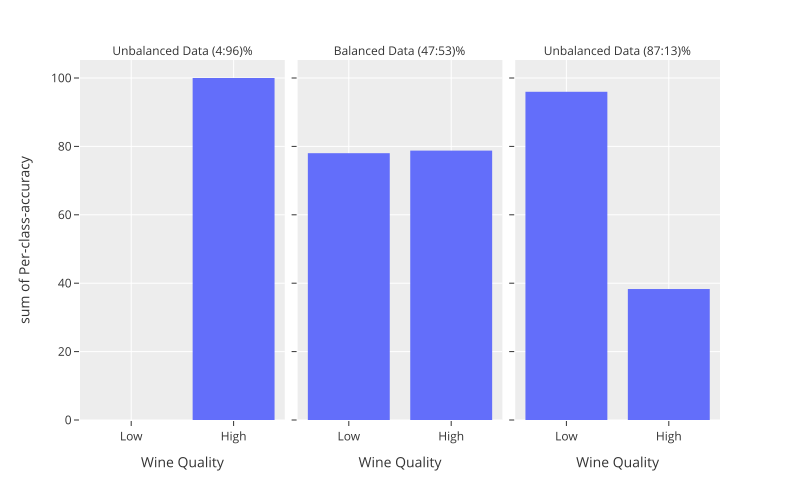

In [44]:
fig = px.histogram(
    per_class_accuracy,
    x='metrics',
    y='metrics_value',
    facet_col='threshold',
    labels={"metrics_value" : 'Per-class-accuracy', 'metrics' : 'Wine Quality'}
)

# Custom subtitles for each facet
custom_titles = {
    '4': 'Unbalanced Data (4:96)%',
    '5': 'Balanced Data (47:53)%',
    '6': 'Unbalanced Data (87:13)%'
}

fig.for_each_annotation(
    lambda a: a.update(text=custom_titles.get(a.text.split("=")[-1], a.text))
)


fig.update_layout(template='ggplot2', width=800)
fig.show(renderer='svg')